In [33]:
# ============================================
# CREDIT CARD FRAUD DETECTION
# 01 - EXPLORATORY DATA ANALYSIS
# ============================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


In [1]:
import os

print(os.getcwd())

C:\Users\Suprajakshaya\Documents\ML_LAB\credit_card\notebooks


In [3]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (284807, 31)


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [13]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

In [15]:
missing_values = df.isnull().sum()

print(missing_values)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [17]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

missing_summary

,Missing Values,Percentage
Time,0,0.0
V16,0,0.0
Amount,0,0.0
V28,0,0.0
V27,0,0.0
V26,0,0.0
V25,0,0.0
V24,0,0.0
V23,0,0.0
V22,0,0.0


In [19]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [21]:
df[df.duplicated()].head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0


In [23]:
print("Shape before removing duplicates:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape before removing duplicates: (284807, 31)
Shape after removing duplicates: (283726, 31)


In [25]:
print("Duplicates remaining:", df.duplicated().sum())

Duplicates remaining: 0


In [27]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [39]:
class_counts = df["Class"].value_counts()
class_percentages = df["Class"].value_counts(normalize=True) * 100

print("Class Distribution:")
print(class_counts)

print("\nClass Percentage:")
print(class_percentages)

Class Distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Class Percentage:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


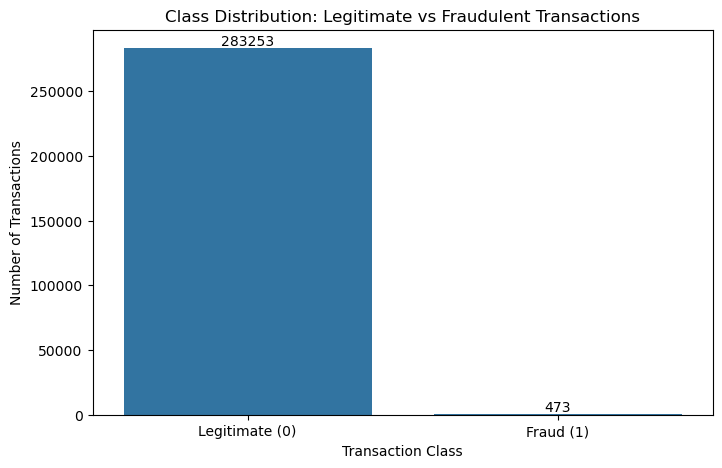

In [41]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x="Class")

plt.title("Class Distribution: Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate (0)", "Fraud (1)"])

# Add counts above bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [43]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

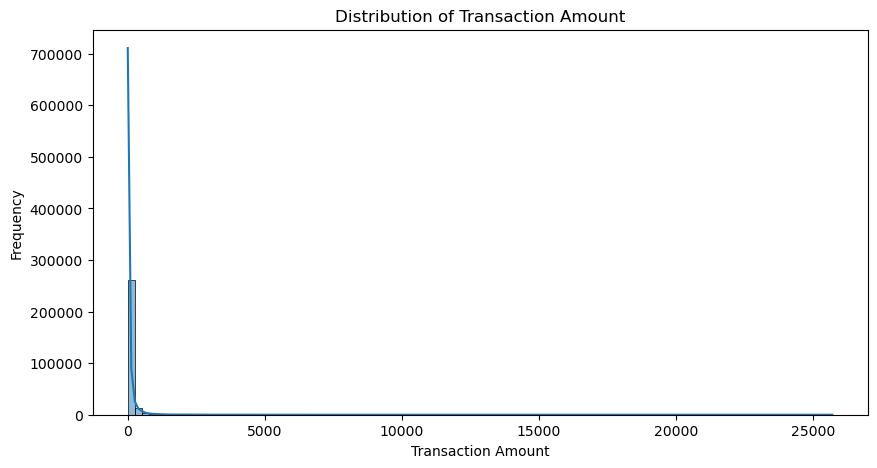

In [45]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Amount"],
    bins=100,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

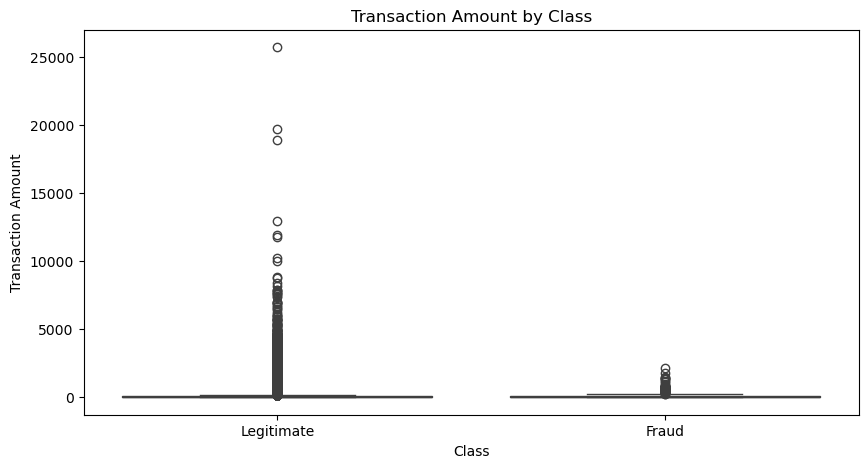

In [47]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

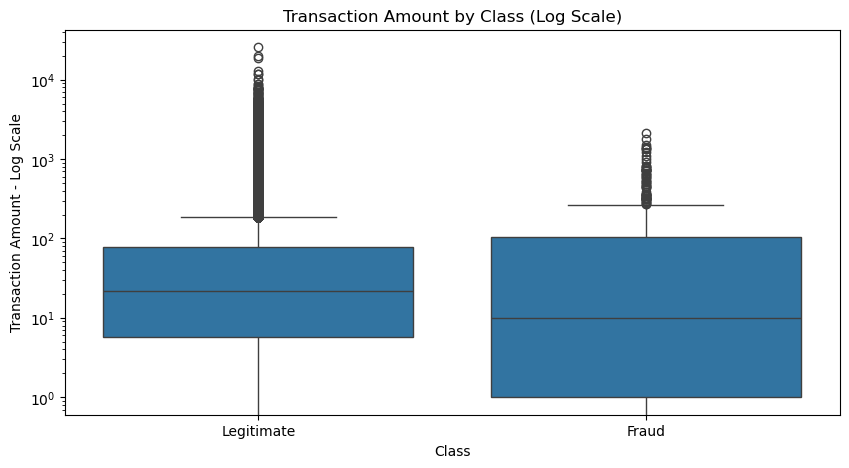

In [49]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.yscale("log")

plt.title("Transaction Amount by Class (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Transaction Amount - Log Scale")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

In [51]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


In [53]:
df["Time"].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

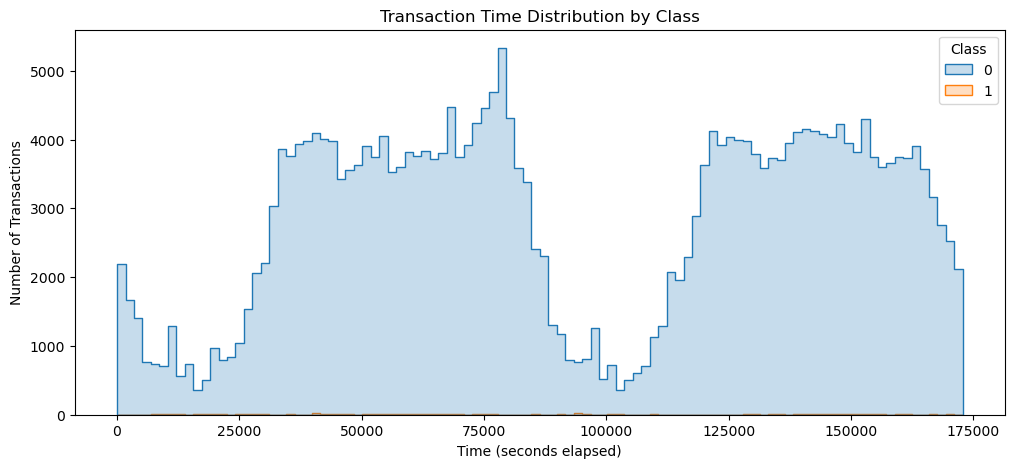

In [55]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    element="step"
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time (seconds elapsed)")
plt.ylabel("Number of Transactions")

plt.show()

In [59]:
df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

df[["Time", "Hour", "Class"]].head()

,Time,Hour,Class
0,0.0,0,0
1,0.0,0,0
2,1.0,0,0
3,1.0,0,0
4,2.0,0,0


In [61]:
df.groupby("Hour")["Class"].mean() * 100

Hour
0     0.078462
1     0.237643
2     1.451028
3     0.487525
4     1.043557
5     0.368139
6     0.220480
7     0.317987
8     0.087959
9     0.101478
10    0.048344
11    0.315833
12    0.110548
13    0.110944
14    0.139225
15    0.158788
16    0.134179
17    0.173590
18    0.165104
19    0.122061
20    0.107752
21    0.090760
22    0.058525
23    0.156207
Name: Class, dtype: float64

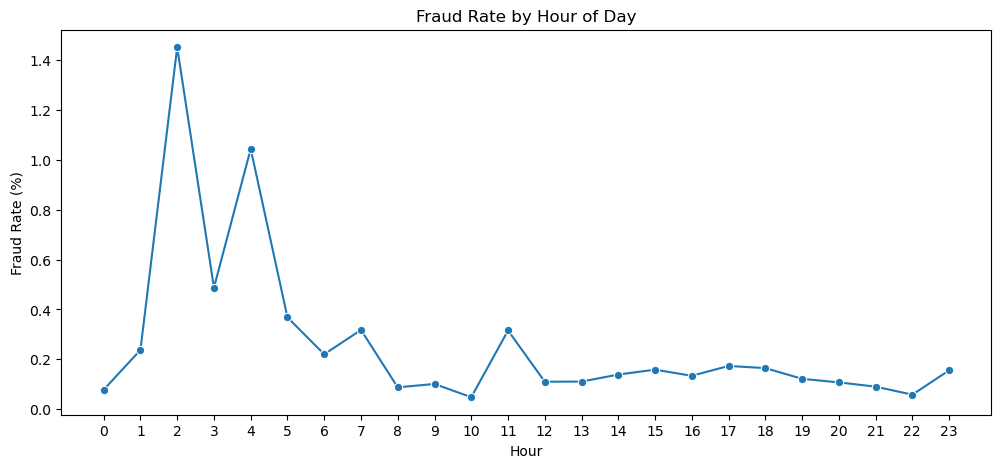

In [63]:
hourly_fraud_rate = df.groupby("Hour")["Class"].mean() * 100

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hourly_fraud_rate.index,
    y=hourly_fraud_rate.values,
    marker="o"
)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.show()

# Check V1–V28 statistics

In [66]:
v_features = [f"V{i}" for i in range(1, 29)]

print(v_features)

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


In [68]:
df[v_features].describe().T

,count,mean,std,min,25%,50%,75%,max
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995
V10,283726.0,-0.001441,1.076407,-24.588262,-0.535578,-0.093237,0.453619,23.745136


In [70]:
class_means = df.groupby("Class")[v_features].mean().T

class_means

Class,0,1
V1,0.013439,-4.498280
V2,-0.009829,3.405965
V3,0.012853,-6.729599
V4,-0.010440,4.472591
V5,0.006769,-2.957197
V6,0.001251,-1.432518
V7,0.010447,-5.175912
V8,-0.002448,0.953255
V9,0.002613,-2.522124
V10,0.007663,-5.453274


## Find features with the biggest difference

In [73]:
mean_difference = (
    df.groupby("Class")[v_features]
    .mean()
    .T
)

mean_difference["Absolute_Difference"] = (
    mean_difference[1] - mean_difference[0]
).abs()

mean_difference = mean_difference.sort_values(
    "Absolute_Difference",
    ascending=False
)

mean_difference.head(10)

Class,0,1,Absolute_Difference
V14,0.011668,-6.835946,6.847614
V3,0.012853,-6.729599,6.742452
V17,0.010963,-6.463285,6.474249
V12,0.009476,-6.103254,6.112730
V10,0.007663,-5.453274,5.460937
V7,0.010447,-5.175912,5.186359
V1,0.013439,-4.498280,4.511719
V4,-0.010440,4.472591,4.483031
V16,0.007845,-4.000956,4.008801
V11,-0.006004,3.716347,3.722350


In [75]:
top_features = mean_difference.head(4).index.tolist()

print("Top features:", top_features)

Top features: ['V14', 'V3', 'V17', 'V12']


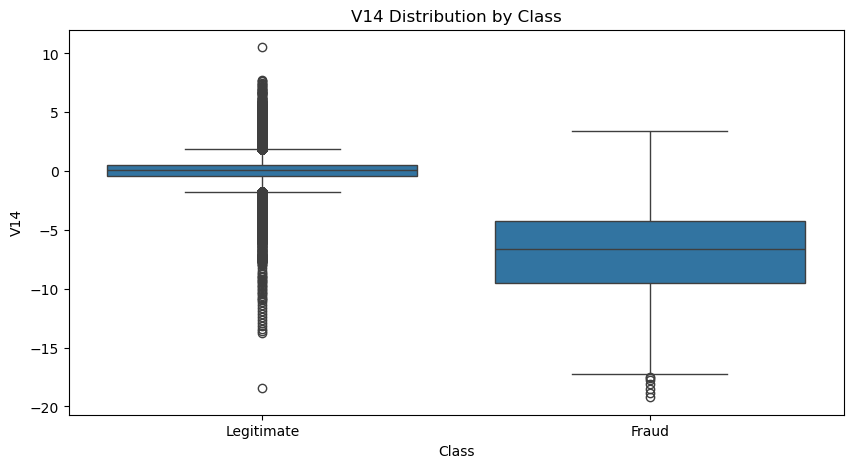

In [77]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y=top_features[0]
)

plt.title(f"{top_features[0]} Distribution by Class")
plt.xlabel("Class")
plt.ylabel(top_features[0])
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

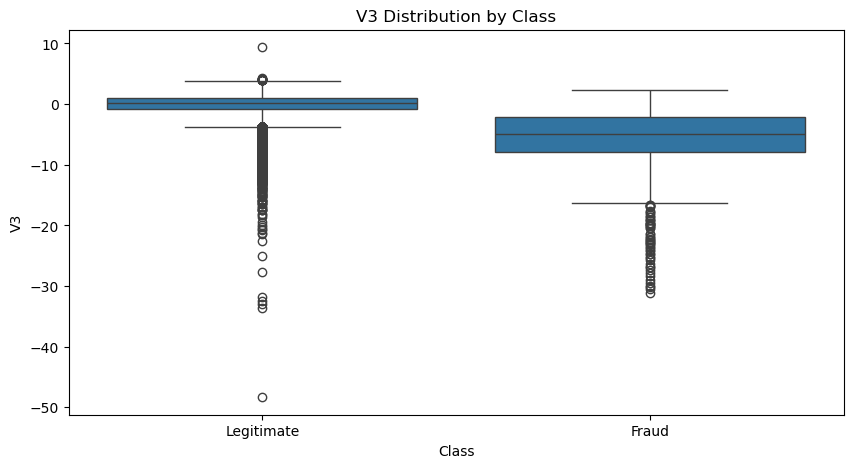

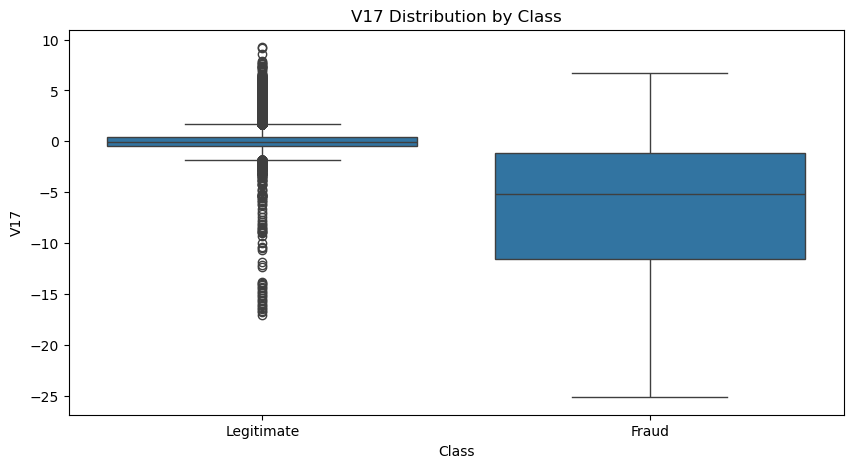

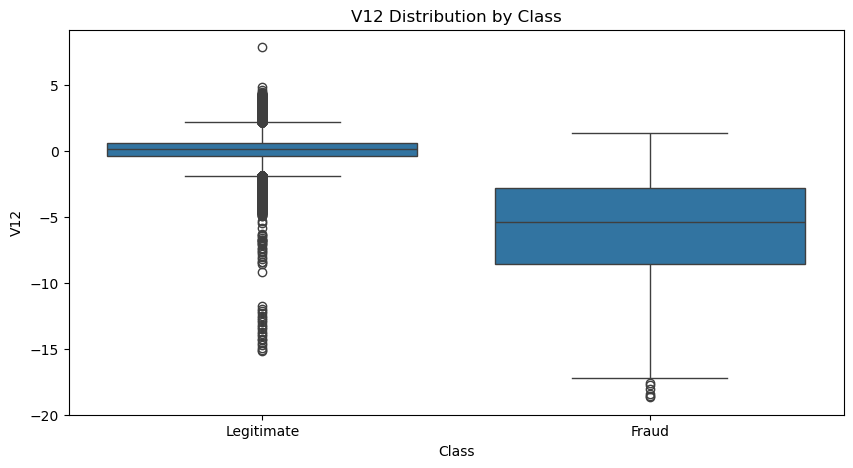

In [79]:
for feature in top_features[1:]:
    plt.figure(figsize=(10, 5))

    sns.boxplot(
        data=df,
        x="Class",
        y=feature
    )

    plt.title(f"{feature} Distribution by Class")
    plt.xlabel("Class")
    plt.ylabel(feature)
    plt.xticks([0, 1], ["Legitimate", "Fraud"])

    plt.show()

# Correlation with the target

In [82]:
correlation_with_target = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values()
)

correlation_with_target

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Hour     -0.016740
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Name: Class, dtype: float64

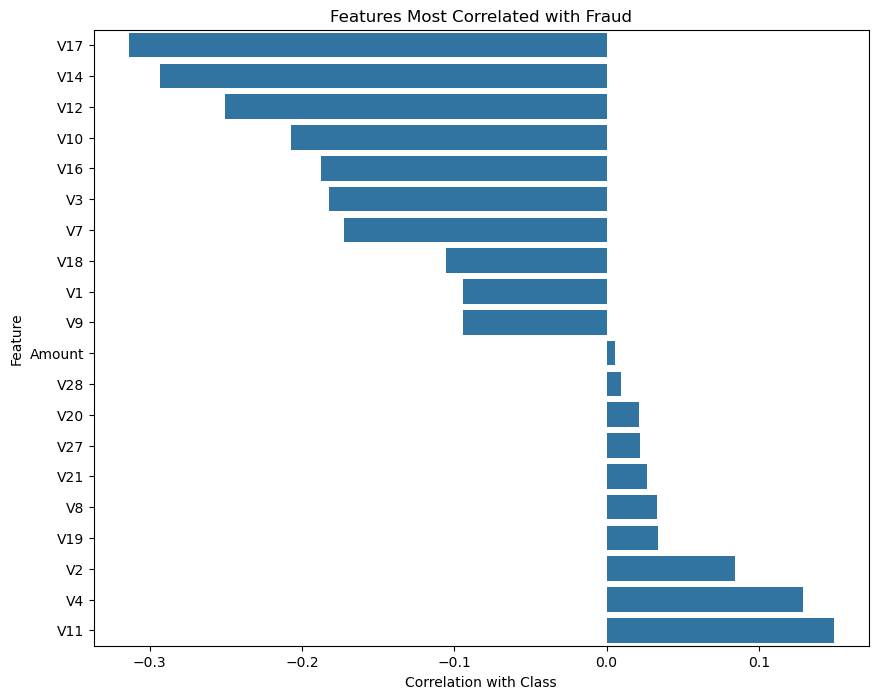

In [84]:
top_correlations = pd.concat([
    correlation_with_target.head(10),
    correlation_with_target.tail(10)
])

plt.figure(figsize=(10, 8))

sns.barplot(
    x=top_correlations.values,
    y=top_correlations.index
)

plt.title("Features Most Correlated with Fraud")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.show()

In [86]:
outlier_summary = pd.DataFrame({
    "Q1": df[v_features].quantile(0.25),
    "Q3": df[v_features].quantile(0.75)
})

outlier_summary["IQR"] = (
    outlier_summary["Q3"] - outlier_summary["Q1"]
)

outlier_summary["Lower_Bound"] = (
    outlier_summary["Q1"] - 1.5 * outlier_summary["IQR"]
)

outlier_summary["Upper_Bound"] = (
    outlier_summary["Q3"] + 1.5 * outlier_summary["IQR"]
)

outlier_summary

,Q1,Q3,IQR,Lower_Bound,Upper_Bound
V1,-0.915951,1.316068,2.232019,-4.263980,4.664096
V2,-0.600321,0.800283,1.400603,-2.701226,2.901188
V3,-0.889682,1.026960,1.916642,-3.764645,3.901923
V4,-0.850134,0.739647,1.589781,-3.234807,3.124319
V5,-0.689830,0.612218,1.302048,-2.642901,2.565290
V6,-0.769031,0.396792,1.165823,-2.517765,2.145527
V7,-0.552509,0.570474,1.122983,-2.236984,2.254949
V8,-0.208828,0.325704,0.534532,-1.010627,1.127502
V9,-0.644221,0.595977,1.240198,-2.504517,2.456273
V10,-0.535578,0.453619,0.989197,-2.019373,1.937414


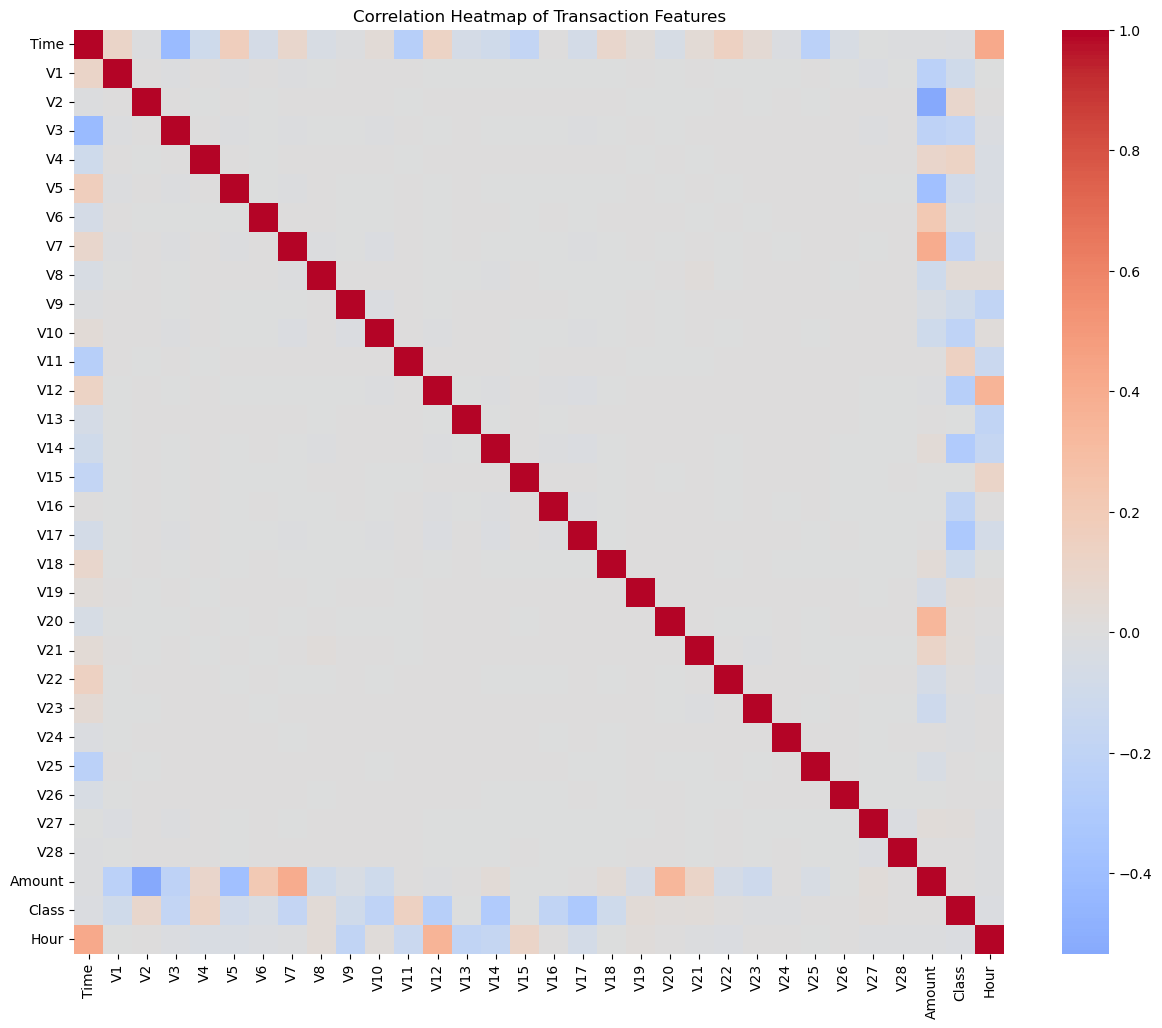

In [88]:
plt.figure(figsize=(15, 12))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Transaction Features")
plt.show()